# Week 8 — LIME on Logistic Regression (Cross-check)
### Bias Analysis in ML Models using Explainable AI
**Model:** LR Balanced (class_weight='balanced')  
**Purpose:** Cross-check against DT LIME results. SHAP revealed LR uses sex as a direct top-3 feature (mean |SHAP| = 0.536) while DT routes bias through proxy features. This notebook tests whether that difference shows up at the individual prediction level.

**Same three individuals as week8_lime.ipynb:**
- Individual A: index 2 — correctly classified high-income Male
- Individual B: index 5 — correctly classified high-income Female  
- Individual C: index 91 — misclassified high-income Female (False Negative)

---

## Why Run LIME on LR at All?

LR is already a linear model. SHAP's LinearExplainer is the more theoretically correct tool for explaining LR predictions. So why LIME?

Because this notebook is not about getting the best explanation of LR — it's about **comparison**. Running LIME on both models with identical individuals lets us ask: does sex appear as a direct driver in LR's local explanations where it was absent in DT's? If yes, we have concrete individual-level evidence that the two models discriminate through different mechanisms — one direct, one through proxies.

> Frame this as a comparison exercise, not as the primary explanation method for LR. SHAP is authoritative for LR. LIME here is a cross-check.

## Section 0 — Imports & Load

In [25]:
%pip install lime

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import lime
import lime.lime_tabular

plt.style.use('seaborn-v0_8-whitegrid')


# Load everything saved from Week 7
lr_bal  = joblib.load('lr_balanced_model.pkl')
dt_bal  = joblib.load('dt_balanced_model.pkl')
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_test  = pd.read_csv('y_test.csv').squeeze()
df_eval = pd.read_csv('df_eval.csv').reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Same indices used in week8_lime.ipynb and week8_SHAP.ipynb
idx_A = 2
idx_B = 5
idx_C = 91

print('All files loaded.')
print(f'Features: {list(X_test.columns)}')

All files loaded.
Features: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


---
## Section 1 — Build LIME Explainer for LR

In [27]:
# Identical setup to week8_lime.ipynb
# Categorical features identified by cardinality threshold
categorical_features = [
    i for i, col in enumerate(X_train.columns)
    if X_train[col].nunique() < 20
]

# categorical_names = {
#     i: list(X_train[col].unique())
#     for i, col in enumerate(X_train.columns)
#     if i in categorical_features
# }

explainer_lr = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_test.columns),
    class_names=['<=50K', '>50K'],
    categorical_features=categorical_features,
    #categorical_names=categorical_names,
    mode='classification',
    random_state=42
)

print('LR LIME explainer built.')

LR LIME explainer built.


---
## Section 2 — LIME Explanations on LR for All Three Individuals

In [28]:
def explain_lr(idx, label, description, num_features=10):
    instance = X_test.iloc[idx].values
    
    exp = explainer_lr.explain_instance(
        data_row=instance,
        predict_fn=lr_bal.predict_proba,
        num_features=num_features,
        num_samples=5000
    )
    
    prob = lr_bal.predict_proba(instance.reshape(1, -1))[0]
    
    print(f'Individual {label} — {description}')
    print(f'  LR: P(<=50K) = {prob[0]:.3f} | P(>50K) = {prob[1]:.3f}')
    print(f'  Prediction: {">"+"50K" if prob[1] > 0.5 else "<="+"50K"}')
    print(f'  True label: {">"+"50K" if y_test.iloc[idx]==1 else "<="+"50K"}')
    print()
    
    fig = exp.as_pyplot_figure(label=1)
    plt.title(f'LIME on LR — Individual {label}\n{description}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'lime_lr_individual_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return exp

### Individual A — Correctly Classified High-Income Male

Individual A — Correctly classified high-income Male
  LR: P(<=50K) = 0.319 | P(>50K) = 0.681
  Prediction: >50K
  True label: >50K



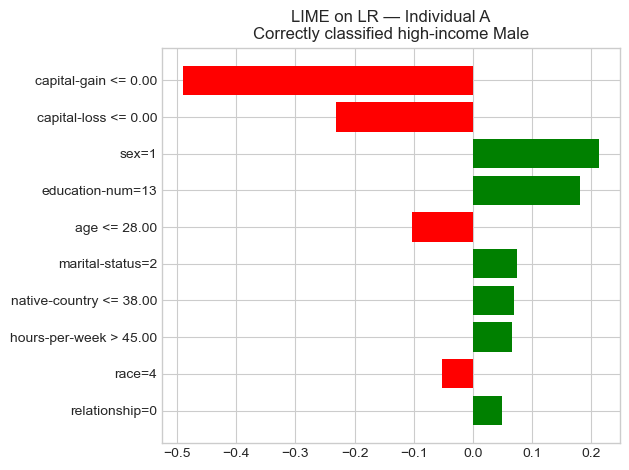

In [29]:
exp_lr_A = explain_lr(idx_A, 'A', 'Correctly classified high-income Male')

### Individual B — Correctly Classified High-Income Female

Individual B — Correctly classified high-income Female
  LR: P(<=50K) = 0.655 | P(>50K) = 0.345
  Prediction: <=50K
  True label: >50K



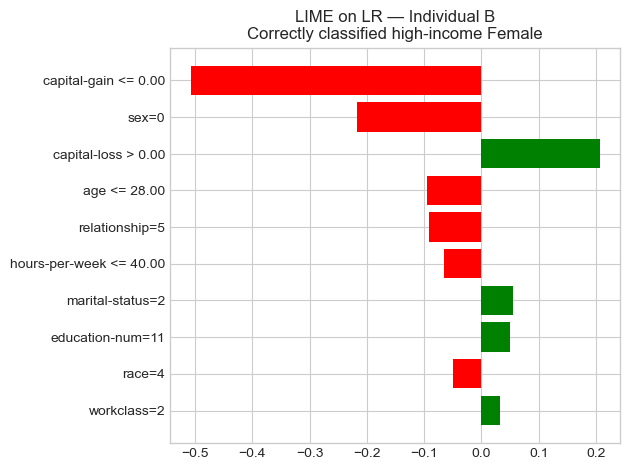

In [30]:
exp_lr_B = explain_lr(idx_B, 'B', 'Correctly classified high-income Female')

### Individual C — Misclassified High-Income Female (False Negative)

Individual C — Misclassified high-income Female (False Negative)
  LR: P(<=50K) = 0.688 | P(>50K) = 0.312
  Prediction: <=50K
  True label: >50K



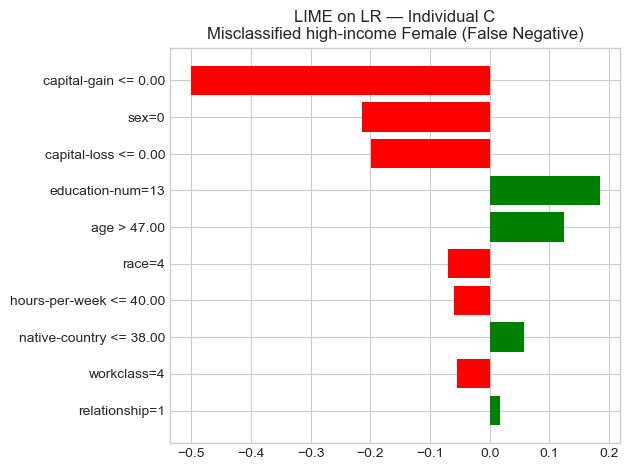

In [31]:
exp_lr_C = explain_lr(idx_C, 'C', 'Misclassified high-income Female (False Negative)')

---
## Section 3 — Does Sex Appear Directly in LR's Local Explanations?

This is the central question. SHAP showed sex as LR's third most important feature globally. Does it show up at the individual level too?

In [32]:
print('=== SEX FEATURE WEIGHT IN LR LIME EXPLANATIONS ===')
print('Positive = pushed toward >50K | Negative = pushed toward <=50K')
print()

for label, exp in [('A', exp_lr_A), ('B', exp_lr_B), ('C', exp_lr_C)]:
    feat_dict = dict(exp.as_list(label=1))
    # Find sex-related entries
    sex_entries = {k: v for k, v in feat_dict.items() if 'sex' in k.lower()}
    if sex_entries:
        for feat, weight in sex_entries.items():
            print(f'  Individual {label}: {feat} = {weight:.4f}')
    else:
        print(f'  Individual {label}: sex did not appear in top {10} features')

print()
print('For comparison — sex weight in DT LIME explanations:')
print('  Individual A: sex=1 = -0.0035 (near zero, DT)')
print('  Individual B: sex did not appear')
print('  Individual C: sex did not appear')

=== SEX FEATURE WEIGHT IN LR LIME EXPLANATIONS ===
Positive = pushed toward >50K | Negative = pushed toward <=50K

  Individual A: sex=1 = 0.2140
  Individual B: sex=0 = -0.2175
  Individual C: sex=0 = -0.2133

For comparison — sex weight in DT LIME explanations:
  Individual A: sex=1 = -0.0035 (near zero, DT)
  Individual B: sex did not appear
  Individual C: sex did not appear


---
## Section 4 — Side-by-Side Comparison: LR vs DT LIME Weights

In [33]:
# DT LIME weights from week8_lime.ipynb — hardcoded from Section 9 summary
dt_top = {
    'A': {
        'capital-gain <= 0.00': -0.4817,
        'relationship=0':        0.4238,
        'education-num=13':      0.0880,
        'native-country <= 38.00': 0.0557,
        'capital-loss <= 0.00':  0.0124,
    },
    'B': {
        'capital-gain <= 0.00': -0.5141,
        'relationship=5':        0.3190,
        'native-country <= 38.00': 0.0433,
        'hours-per-week <= 40.00': -0.0151,
        'age <= 28.00':          -0.0136,
    },
    'C': {
        'capital-gain <= 0.00': -0.4742,
        'relationship=1':       -0.2918,
        'education-num=13':      0.0888,
        'marital-status=3':      0.0334,
        'capital-loss <= 0.00':  0.0162,
    }
}

# LR LIME weights — from this notebook
print('=== LR vs DT LIME — TOP FEATURES COMPARISON ===')
print()

for label, exp in [('A', exp_lr_A), ('B', exp_lr_B), ('C', exp_lr_C)]:
    lr_features = exp.as_list(label=1)[:5]
    print(f'--- Individual {label} ---')
    print(f'{"Feature":<40} {"LR Weight":>12} {"DT Weight":>12}')
    print('-' * 66)
    
    # Print LR top features with DT equivalent if exists
    for feat, lr_w in lr_features:
        dt_w = dt_top[label].get(feat, 'N/A')
        dt_str = f'{dt_w:>12.4f}' if isinstance(dt_w, float) else f'{dt_w:>12}'
        print(f'{feat:<40} {lr_w:>12.4f} {dt_str}')
    print()

=== LR vs DT LIME — TOP FEATURES COMPARISON ===

--- Individual A ---
Feature                                     LR Weight    DT Weight
------------------------------------------------------------------
capital-gain <= 0.00                          -0.4906      -0.4817
capital-loss <= 0.00                          -0.2308       0.0124
sex=1                                          0.2140          N/A
education-num=13                               0.1811       0.0880
age <= 28.00                                  -0.1022          N/A

--- Individual B ---
Feature                                     LR Weight    DT Weight
------------------------------------------------------------------
capital-gain <= 0.00                          -0.5082      -0.5141
sex=0                                         -0.2175          N/A
capital-loss > 0.00                            0.2064          N/A
age <= 28.00                                  -0.0944      -0.0136
relationship=5                       

---
## Section 5 — Visual Comparison: LR vs DT for Individual C

Individual C is the most analytically important case. Side-by-side shows whether the two models fail her for the same reason or different reasons.

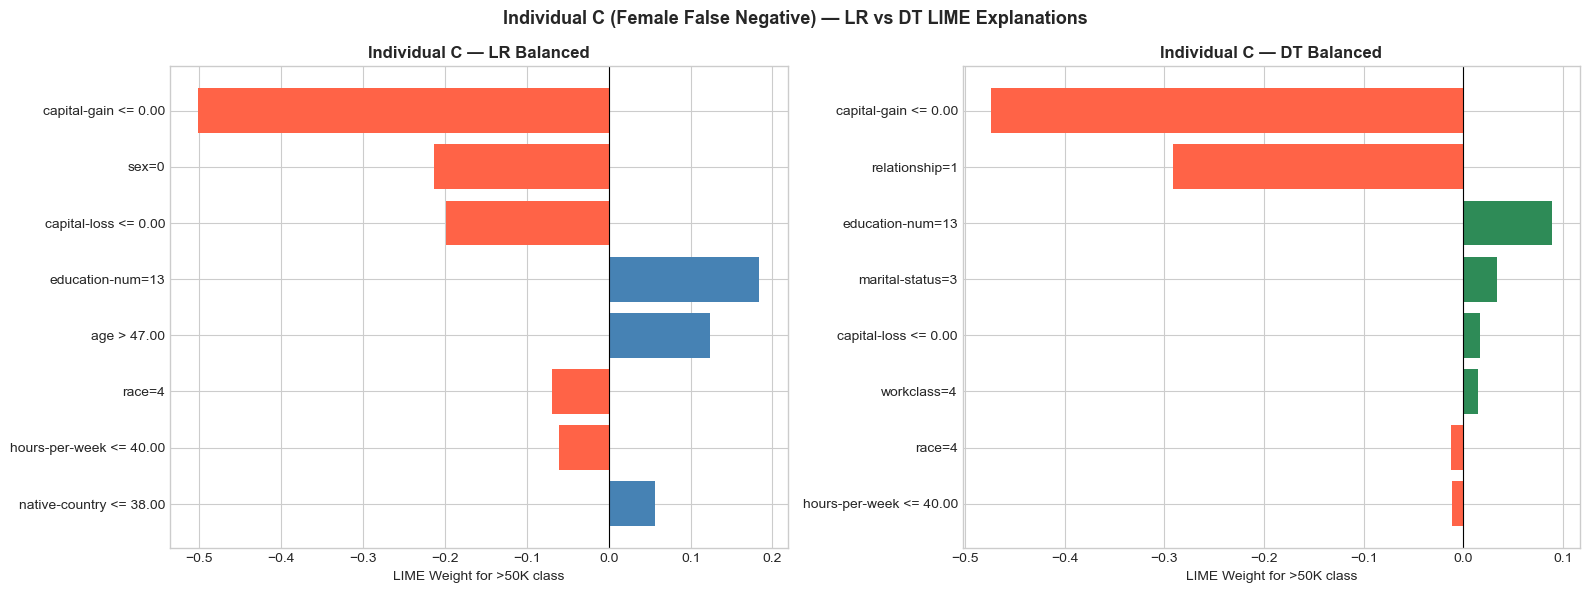

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR explanation for C
lr_features_C = exp_lr_C.as_list(label=1)[:8]
lr_names  = [f[0] for f in lr_features_C]
lr_weights = [f[1] for f in lr_features_C]
lr_colors = ['tomato' if w < 0 else 'steelblue' for w in lr_weights]
axes[0].barh(lr_names[::-1], lr_weights[::-1], color=lr_colors[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Individual C — LR Balanced', fontsize=12, fontweight='bold')
axes[0].set_xlabel('LIME Weight for >50K class')

# DT explanation for C — from saved values
dt_features_C = [
    ('capital-gain <= 0.00', -0.4742),
    ('relationship=1',       -0.2918),
    ('education-num=13',      0.0888),
    ('marital-status=3',      0.0334),
    ('capital-loss <= 0.00',  0.0162),
    ('workclass=4',           0.0145),
    ('race=4',               -0.0124),
    ('hours-per-week <= 40.00', -0.0118),
]
dt_names   = [f[0] for f in dt_features_C]
dt_weights = [f[1] for f in dt_features_C]
dt_colors  = ['tomato' if w < 0 else 'seagreen' for w in dt_weights]
axes[1].barh(dt_names[::-1], dt_weights[::-1], color=dt_colors[::-1])
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Individual C — DT Balanced', fontsize=12, fontweight='bold')
axes[1].set_xlabel('LIME Weight for >50K class')

plt.suptitle(
    'Individual C (Female False Negative) — LR vs DT LIME Explanations',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_lr_vs_dt_individual_C.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Analysis

> **Fill in after running the notebook. Answer these questions:**
>
> **On sex appearing directly:**
> - Does sex appear in LR's local explanations for any of the three individuals?
> - If yes — what is its weight and direction? Is it negative for females?
> - Does it appear for Individual C specifically — the false negative?
>
> **On the mechanism of discrimination:**
> - DT discriminates through relationship (a proxy). Does LR also use relationship, or does it route through different features?
> - If LR uses sex directly AND relationship — does that make it doubly penalising for women?
> - If LR uses sex directly but DT doesn't — what does that tell us about which model is more transparently biased vs more opaquely biased?
>
> **On confidence:**
> - What is LR's confidence on Individual C? Is it more or less confident in the wrong direction than DT (which was 86.1%)?
> - Does a more confident wrong prediction from LR align with its higher Female FNR (0.647 vs DT's 0.271)?

---
## Section 7 — Key Takeaway

After filling in your analysis, document the conclusion here in one paragraph for the merged report:

> **Template:** *LR Balanced [does/does not] use sex as a direct driver in its local explanations for Individual C. [If yes: sex appears with weight X, meaning it directly penalises/benefits the female classification.] DT Balanced in contrast routes its bias through relationship status. This means the two models are not just different in accuracy — they are biased through structurally different mechanisms. LR's more direct use of sex as a feature may explain its significantly higher Female FNR (0.647) compared to DT's (0.271).*

In [35]:
# Summary printout for merged report
print('=== LR LIME SUMMARY FOR MERGED REPORT ===')
print()
for label, exp in [('A', exp_lr_A), ('B', exp_lr_B), ('C', exp_lr_C)]:
    prob = lr_bal.predict_proba(X_test.iloc[{
        'A': idx_A, 'B': idx_B, 'C': idx_C
    }[label]].values.reshape(1, -1))[0]
    top = exp.as_list(label=1)[:5]
    print(f'Individual {label}: P(>50K) = {prob[1]:.3f}')
    for feat, weight in top:
        direction = '→ >50K' if weight > 0 else '→ <=50K'
        print(f'  {feat:<45} {weight:>8.4f}  {direction}')
    print()

=== LR LIME SUMMARY FOR MERGED REPORT ===

Individual A: P(>50K) = 0.681
  capital-gain <= 0.00                           -0.4906  → <=50K
  capital-loss <= 0.00                           -0.2308  → <=50K
  sex=1                                           0.2140  → >50K
  education-num=13                                0.1811  → >50K
  age <= 28.00                                   -0.1022  → <=50K

Individual B: P(>50K) = 0.345
  capital-gain <= 0.00                           -0.5082  → <=50K
  sex=0                                          -0.2175  → <=50K
  capital-loss > 0.00                             0.2064  → >50K
  age <= 28.00                                   -0.0944  → <=50K
  relationship=5                                 -0.0922  → <=50K

Individual C: P(>50K) = 0.312
  capital-gain <= 0.00                           -0.5010  → <=50K
  sex=0                                          -0.2133  → <=50K
  capital-loss <= 0.00                           -0.1990  → <=50K
  educatio